# EDA

*Exploratory Data Analysis (EDA) is an approach/philosophy for data analysis that employs a variety of techniques (mostly graphical) to.*

<img src ="https://www.statistika.co/images/services/Exploratory%20Data%20Analysis%20-%20EDA%201000x468.jpg"/>

We will be performing EDA in two dataset **Titanic Dataset** and **Student Performance in Exam Dataset**.

# Import Libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn import preprocessing

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Titanic Data

In [2]:
train = pd.read_csv('/kaggle/input/titanic/train.csv')

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Exploratory Data Analysis

**Finding if there is NULL value**

In [4]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

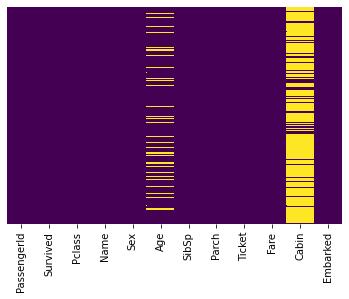

In [5]:
sns.heatmap(train.isnull(), yticklabels = False, cbar=False, cmap='viridis')



Roughly 20 percent of the Age data is missing. The proportion of Age missing is likely small enough for reasonable replacement with some form of imputation. Looking at the Cabin column, it looks like we are just missing too much of that data to do something useful with at a basic level. We'll probably drop this later, or change it to another feature like "Cabin Known: 1 or 0"

Let's continue on by visualizing some more of the data! Check out the video for full explanations over these plots, this code is just to serve as reference.


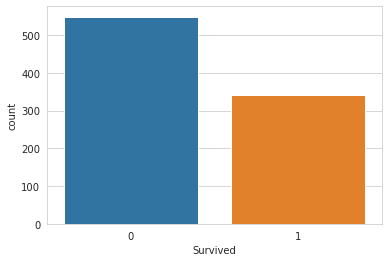

In [6]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', data=train)

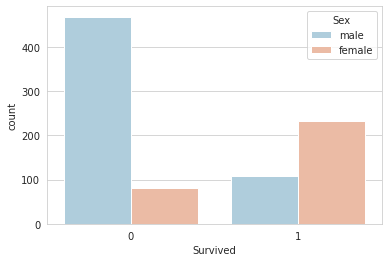

In [7]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Sex', data=train, palette='RdBu_r')

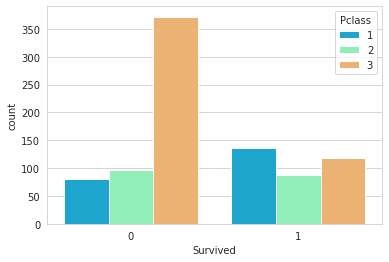

In [8]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Pclass', data=train, palette='rainbow')

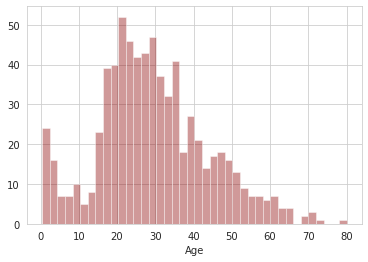

In [9]:
sns.distplot(train['Age'].dropna(), kde = False, color = 'darkred', bins=40)

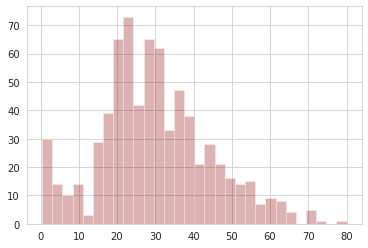

In [10]:
train['Age'].hist(bins=30, color='darkred', alpha=0.3)

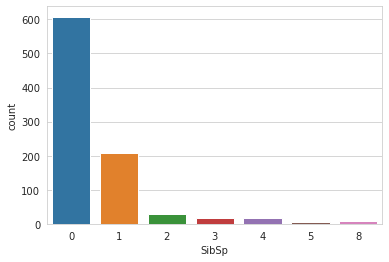

In [11]:
sns.countplot(x='SibSp', data=train)

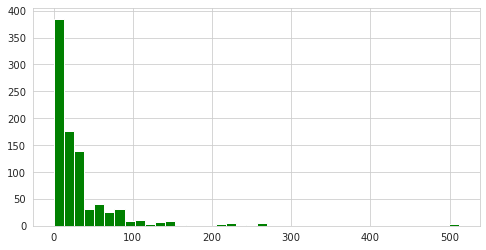

In [12]:
train['Fare'].hist(bins=40, color='green', figsize=(8,4))

# Data Cleaning

**We want to fill in missing age data instead of just dropping the missing age data rows. One way to do this is by filling in the mean age of all the passengers (imputation). However we can be smarter about this and check the average age by passenger class. For example:**

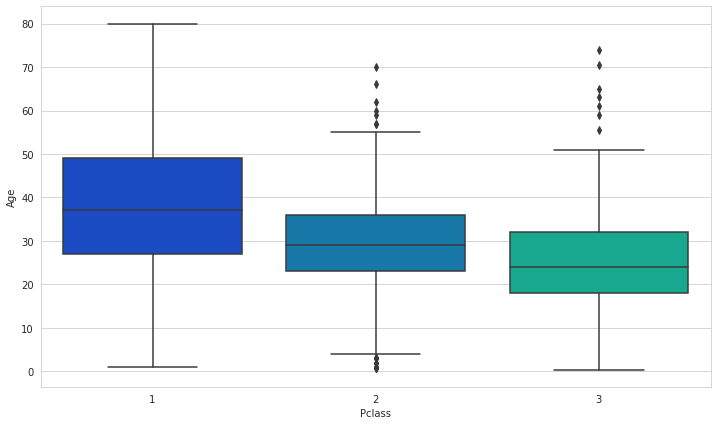

In [13]:
plt.figure(figsize = (12,7))
sns.boxplot(x='Pclass', y='Age', data=train, palette='winter')

**We can see the wealthier passengers in the higher classes tend to be older, which makes sense. We'll use these average age values to impute based on Pclass for Age.**

In [14]:
def impute_age(cols):
    Age = cols[0]
    Pclass = cols[1]
    
    if pd.isnull(Age):
        
        if Pclass == 1 :
            return 37
        elif Pclass == 2:
            return 29
        else:
            return 24
    else:
        return Age

**Now apply that function!**

In [15]:
train['Age'] = train[['Age', 'Pclass']].apply(impute_age, axis=1)

**Now let's check that heat map again!**

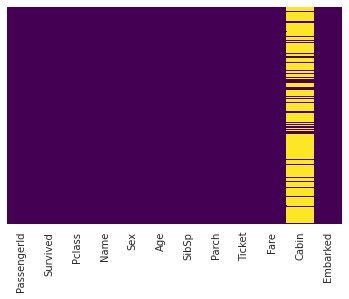

In [16]:
sns.heatmap(train.isnull(), yticklabels = False, cbar=False, cmap='viridis')

**Great! Let's go ahead and drop the Cabin column and the row in Embarked that is NaN.**

In [17]:
train.drop('Cabin', axis=1, inplace=True)

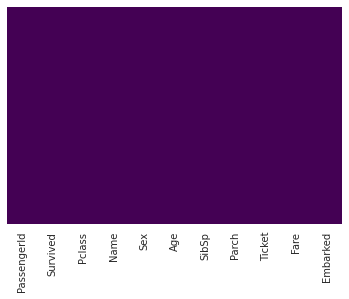

In [18]:
sns.heatmap(train.isnull(), yticklabels = False, cbar=False, cmap='viridis')

# Converting Categorical Features

**We'll need to convert categorical features to dummy variables using pandas! Otherwise our machine learning algorithm won't be able to directly take in those features as inputs.**

In [19]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [20]:
pd.get_dummies(train['Embarked'], drop_first=True).head()

,Q,S
0,0,1
1,0,0
2,0,1
3,0,1
4,0,1


In [21]:
embark = pd.get_dummies(train['Embarked'], drop_first = True)
sex = pd.get_dummies(train['Sex'], drop_first = True)

In [22]:
train.drop(['Sex', 'Embarked', 'Name', 'Ticket'], axis = 1, inplace = True)

In [23]:
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


In [24]:
train = pd.concat([train, sex, embark], axis = 1)

In [25]:
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,1,0,1
1,2,1,1,38.0,1,0,71.2833,0,0,0
2,3,1,3,26.0,0,0,7.9250,0,0,1
3,4,1,1,35.0,1,0,53.1000,0,0,1
4,5,0,3,35.0,0,0,8.0500,1,0,1


# Applying CatBoostClassifier

In [26]:
from catboost import CatBoostClassifier

In [27]:
# Making Features and Target Seperate from dataset
X = train.drop(['Survived'], axis=1)
Y = train['Survived']

# Taking 80% data for training
xtrain,xtest,ytrain,ytest = train_test_split(X,Y,train_size=0.8,random_state=42)

In [28]:
model_LR = clf =CatBoostClassifier(eval_metric='Accuracy',use_best_model=True,random_seed=42)

#now just to make the model to fit the data
clf.fit(xtrain,ytrain,eval_set=(xtest,ytest), early_stopping_rounds=50)

Learning rate set to 0.029139
0:	learn: 0.8412921	test: 0.8212291	best: 0.8212291 (0)	total: 56.6ms	remaining: 56.6s
1:	learn: 0.8314607	test: 0.8100559	best: 0.8212291 (0)	total: 58.6ms	remaining: 29.2s
2:	learn: 0.8300562	test: 0.8100559	best: 0.8212291 (0)	total: 60.3ms	remaining: 20s
3:	learn: 0.8384831	test: 0.8044693	best: 0.8212291 (0)	total: 61.8ms	remaining: 15.4s
4:	learn: 0.8384831	test: 0.8044693	best: 0.8212291 (0)	total: 63.3ms	remaining: 12.6s
5:	learn: 0.8384831	test: 0.8044693	best: 0.8212291 (0)	total: 65ms	remaining: 10.8s
6:	learn: 0.8370787	test: 0.7988827	best: 0.8212291 (0)	total: 66.5ms	remaining: 9.43s
7:	learn: 0.8356742	test: 0.7988827	best: 0.8212291 (0)	total: 68.1ms	remaining: 8.44s
8:	learn: 0.8370787	test: 0.7988827	best: 0.8212291 (0)	total: 69.1ms	remaining: 7.61s
9:	learn: 0.8370787	test: 0.7988827	best: 0.8212291 (0)	total: 70.2ms	remaining: 6.95s
10:	learn: 0.8356742	test: 0.7988827	best: 0.8212291 (0)	total: 71.6ms	remaining: 6.44s
11:	learn: 0.838

In [29]:
model_LR.score(xtest, ytest)

0.8212290502793296

# Students Performance in Exams


In [30]:
# Import Student Data 
data = pd.read_csv('/kaggle/input/students-performance-in-exams/StudentsPerformance.csv')

In [31]:
#Seeing the first 10 Data
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


**Descriptive statistics include those that summarize the central tendency, dispersion and shape of a dataset’s distribution,**

In [32]:
data.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [33]:
data.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

**Finding Unique Value in each Columns(nunique ---> Number of Unique)**

In [34]:
data.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

**Seeing Unique Values in gender column**

In [35]:
data['gender'].unique()

array(['female', 'male'], dtype=object)

# Cleaning the data

In [36]:
#Finding the number of null values 
data.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [37]:
# Remove the Irrelevent Columns
student = data.drop(['race/ethnicity','parental level of education'], axis=1)

In [38]:
student.head()

,gender,lunch,test preparation course,math score,reading score,writing score
0,female,standard,none,72,72,74
1,female,standard,completed,69,90,88
2,female,standard,none,90,95,93
3,male,free/reduced,none,47,57,44
4,male,standard,none,76,78,75


# Relationship Analysis

In [39]:
# Finding the correlation of student data
correlation = student.corr()

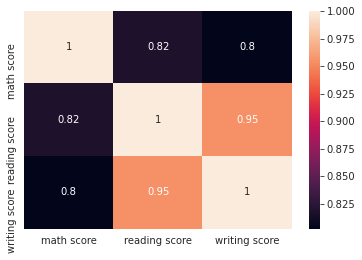

In [40]:
# Visualizing the correlation of the student data
sns.heatmap(correlation, xticklabels = correlation.columns, yticklabels = correlation.columns, annot = True)

**Pairplot plot pairwise relationships in a dataset. By default, this function will create a grid of Axes such that each numeric variable in data will by shared in the y-axis across a single row and in the x-axis across a single column. The diagonal Axes are treated differently, drawing a plot to show the univariate distribution of the data for the variable in that column.**

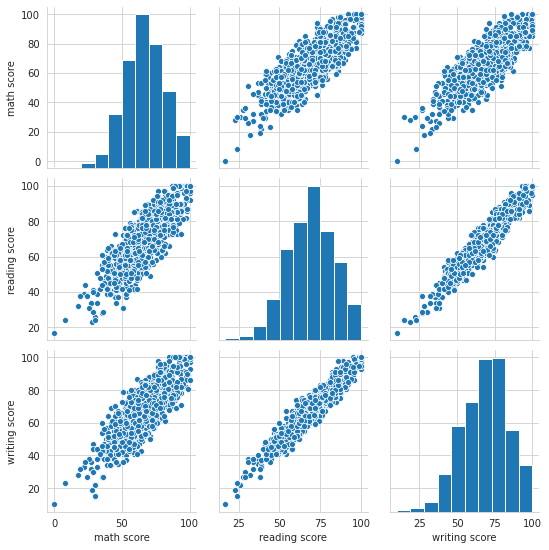

In [41]:
sns.pairplot(student)

**replot shows relationship between variables.**

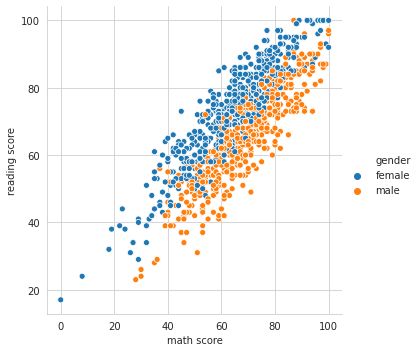

In [42]:
sns.relplot(x = 'math score', y = 'reading score', hue = 'gender', data = student)

**Distplot draw a histogram and fit a kernel density estimate (KDE).**

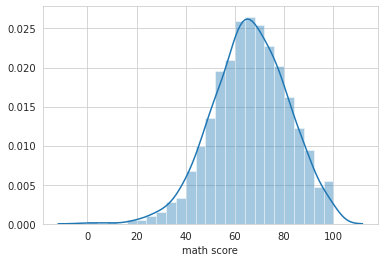

In [43]:
sns.distplot(student['math score'])

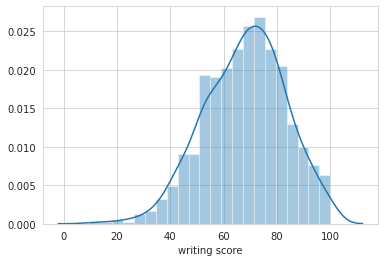

In [44]:
sns.distplot(student['writing score'])

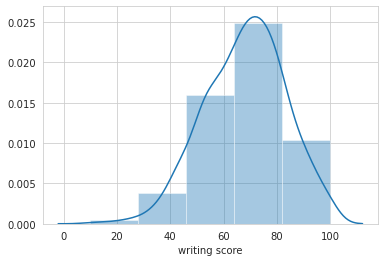

In [45]:
sns.distplot(student['writing score'], bins=5)

**In descriptive statistics, a box plot or boxplot is a method for graphically depicting groups of numerical data through their quartiles.**

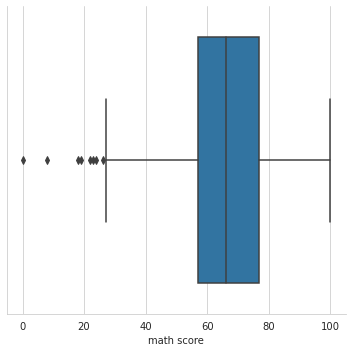

In [46]:
sns.catplot(x='math score', kind='box', data = student)